Instalaciones y librerías

In [1]:
# Instalaciones necesarias (si falta alguna)
!pip install seaborn pandas numpy matplotlib scikit-learn

# Importar librerías
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Configurar visualizaciones
sns.set_style("whitegrid")
%matplotlib inline

**Carga y Business Understanding**

In [2]:
# 1. Business Understanding
print("="*50)
print("PROBLEMA: Predecir si un pasajero del Titanic sobrevive o no")
print("VARIABLE OBJETIVO: 'survived' (0 = No sobrevive, 1 = Sobrevive)")
print("JUSTIFICACIÓN: Relevante para entender factores de supervivencia en desastres")
print("CRITERIO DE ÉXITO PRINCIPAL: Recall (para minimizar falsos negativos - personas que mueren predichas como vivas)")
print("Métrica secundaria: Accuracy y F1-Score")
print("="*50)

PROBLEMA: Predecir si un pasajero del Titanic sobrevive o no
VARIABLE OBJETIVO: 'survived' (0 = No sobrevive, 1 = Sobrevive)
JUSTIFICACIÓN: Relevante para entender factores de supervivencia en desastres
CRITERIO DE ÉXITO PRINCIPAL: Recall (para minimizar falsos negativos - personas que mueren predichas como vivas)
Métrica secundaria: Accuracy y F1-Score


**Data Understanding - Carga y exploración**

In [3]:
# Cargar dataset
titanic = sns.load_dataset('titanic')

# Ver primeras filas
print("Primeras 5 filas:")
print(titanic.head())

# Información general
print("\nInformación del dataset:")
print(titanic.info())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(titanic.describe(include='all'))

# Ver valores nulos
print("\nValores nulos por columna:")
print(titanic.isnull().sum())

# Ver distribución de la variable objetivo
print("\nDistribución de 'survived':")
print(titanic['survived'].value_counts(normalize=True))

Primeras 5 filas:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ---------

**Visualizaciones iniciales**

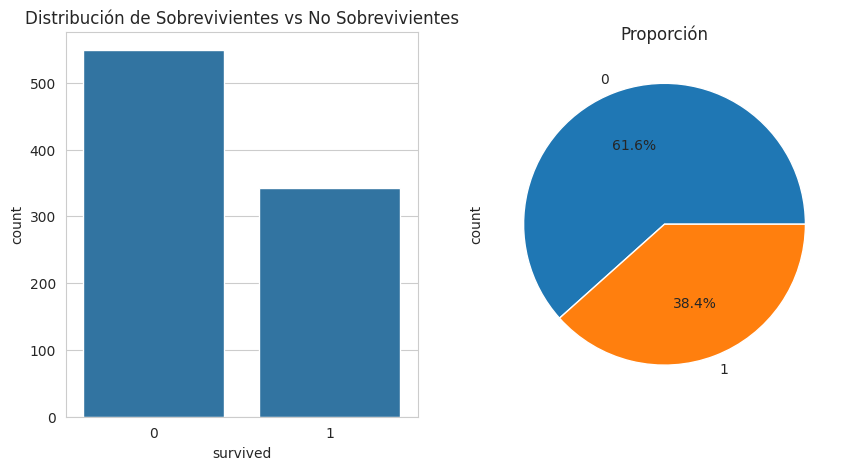

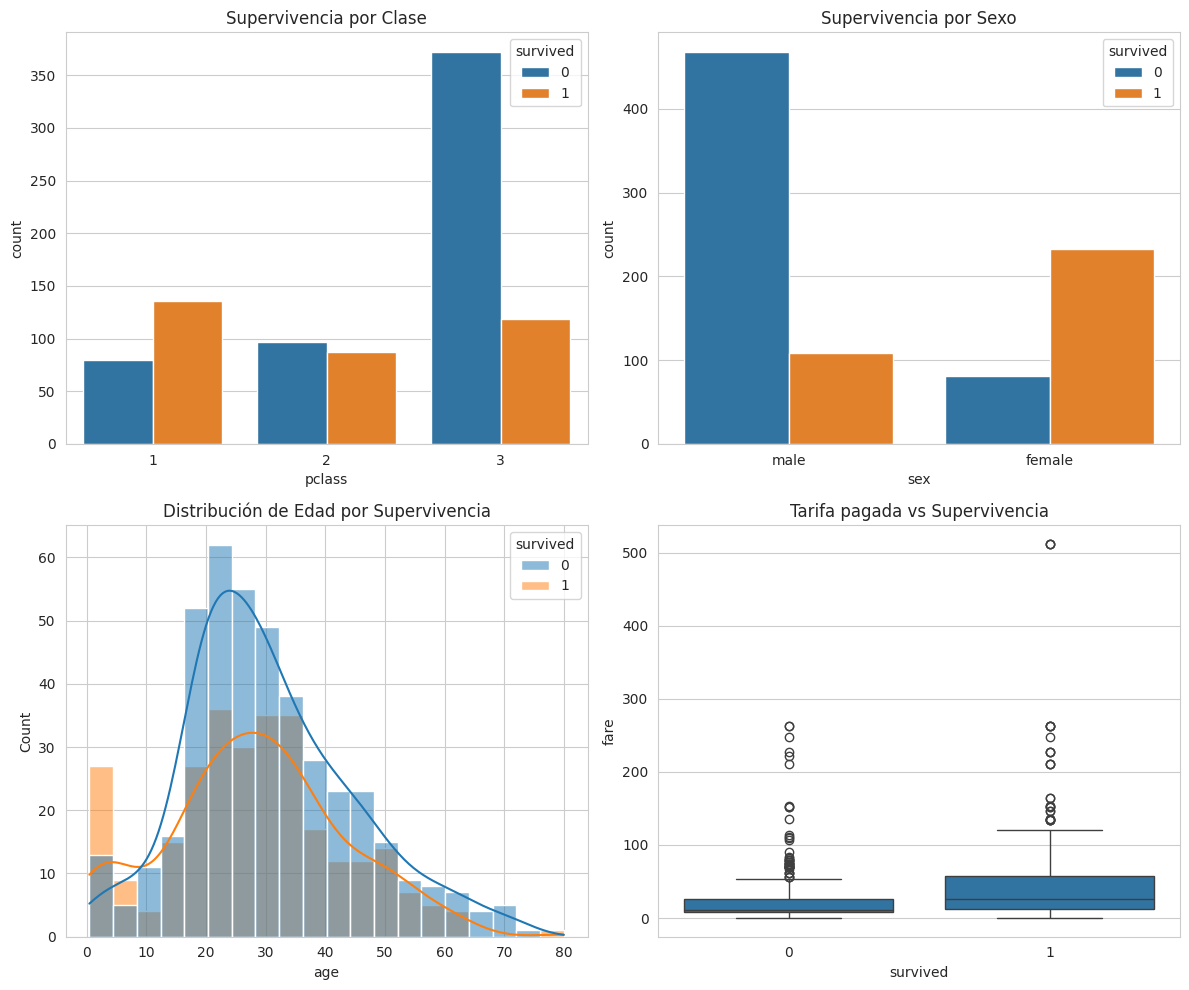

In [4]:
# Figura 1: Distribución de supervivencia
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.countplot(x='survived', data=titanic)
plt.title('Distribución de Sobrevivientes vs No Sobrevivientes')
plt.subplot(1,2,2)
titanic['survived'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Proporción')
plt.show()

# Figura 2: Relación con clase, sexo, edad
fig, axes = plt.subplots(2,2, figsize=(12,10))
sns.countplot(x='pclass', hue='survived', data=titanic, ax=axes[0,0])
axes[0,0].set_title('Supervivencia por Clase')
sns.countplot(x='sex', hue='survived', data=titanic, ax=axes[0,1])
axes[0,1].set_title('Supervivencia por Sexo')
sns.histplot(x='age', hue='survived', data=titanic, kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribución de Edad por Supervivencia')
sns.boxplot(x='survived', y='fare', data=titanic, ax=axes[1,1])
axes[1,1].set_title('Tarifa pagada vs Supervivencia')
plt.tight_layout()
plt.show()

**Data Preparation Parte I - Identificación de problemas**

In [5]:
# Identificar columnas con nulos
null_cols = titanic.isnull().sum()
print("Columnas con valores nulos:")
print(null_cols[null_cols > 0])

# Variables categóricas y numéricas
categorical_cols = titanic.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = titanic.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Quitamos la variable objetivo de numéricas
numerical_cols.remove('survived')

print("\nVariables categóricas:", categorical_cols)
print("Variables numéricas (excluyendo 'survived'):", numerical_cols)

# Decisión: Eliminaremos 'deck' por alta cantidad de nulos (~77% nulos)
# 'embark_town' y 'embarked' tienen pocos nulos, se imputarán con moda
# 'age' tiene ~20% nulos, se imputará con mediana
# 'alive' y 'who' son redundantes, las eliminaremos
# 'adult_male' también redundante con 'sex' y 'age'
# 'alone' puede ser relevante pero la dejamos
# 'class' es redundante con 'pclass'

Columnas con valores nulos:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Variables categóricas: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']
Variables numéricas (excluyendo 'survived'): ['pclass', 'age', 'sibsp', 'parch', 'fare']


**Data Preparation Parte I - Limpieza inicial**

In [6]:
# Copia para preprocesar
df = titanic.copy()

# Eliminar columnas redundantes o con muchos nulos
cols_to_drop = ['deck', 'alive', 'who', 'adult_male', 'class', 'embark_town']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Verificar nulos después de eliminar
print("Nulos después de limpieza inicial:")
print(df.isnull().sum())

# Imputación de nulos (se hará en pipeline más adelante, pero mostramos decisión)
print("\nDecisiones de imputación:")
print("- 'age': mediana (porque tiene distribución asimétrica)")
print("- 'embarked': moda (solo 2 nulos)")
print("- 'fare': no hay nulos, se mantiene")
print("- 'sex', 'pclass', 'sibsp', 'parch', 'alone' no tienen nulos")

Nulos después de limpieza inicial:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
alone         0
dtype: int64

Decisiones de imputación:
- 'age': mediana (porque tiene distribución asimétrica)
- 'embarked': moda (solo 2 nulos)
- 'fare': no hay nulos, se mantiene
- 'sex', 'pclass', 'sibsp', 'parch', 'alone' no tienen nulos


**Data Preparation Parte II - Transformaciones y división**

In [7]:
# Separar variables predictoras (X) y objetivo (y)
X = df.drop('survived', axis=1)
y = df['survived']

# Identificar columnas numéricas y categóricas después de limpieza
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked', 'pclass', 'alone']

# Nota: 'pclass' es ordinal, pero la trataremos como categórica
# 'alone' es booleana, la tratamos como categórica

# Crear preprocesador con Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Dividir en entrenamiento y prueba (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")

Tamaño entrenamiento: (712, 8)
Tamaño prueba: (179, 8)


**Celda 8: Modeling - Entrenar dos modelos**

In [8]:
# Modelo 1: Regresión Logística
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Modelo 2: Árbol de Decisión
tree_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Entrenar
log_reg.fit(X_train, y_train)
tree_clf.fit(X_train, y_train)

# Predicciones
y_pred_log = log_reg.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)

**Evaluation - Métricas y selección del mejor modelo**

=== MÉTRICAS EN CONJUNTO DE PRUEBA ===

Regresión Logística:
  Accuracy:  0.8212
  Precision: 0.8246
  Recall:    0.6812
  F1-Score:  0.7460

Árbol de Decisión:
  Accuracy:  0.7989
  Precision: 0.7463
  Recall:    0.7246
  F1-Score:  0.7353

=== COMPARACIÓN ===
Mejor modelo según Recall (criterio de éxito): Árbol de Decisión con Recall = 0.7246
Nota: Se prefiere Recall porque queremos minimizar los falsos negativos (personas que mueren pero el modelo predice que sobreviven).


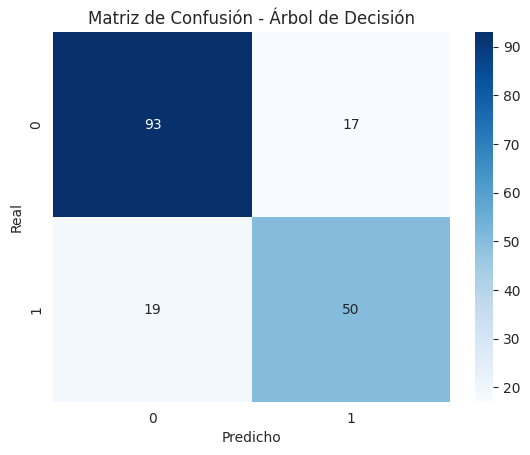


Reporte de clasificación detallado (mejor modelo):
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.75      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [9]:
# Calcular métricas para ambos modelos
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    return {'acc':acc, 'prec':prec, 'rec':rec, 'f1':f1}

print("=== MÉTRICAS EN CONJUNTO DE PRUEBA ===")
metrics_log = evaluate_model(y_test, y_pred_log, "Regresión Logística")
metrics_tree = evaluate_model(y_test, y_pred_tree, "Árbol de Decisión")

# Comparación
print("\n=== COMPARACIÓN ===")
if metrics_log['rec'] >= metrics_tree['rec']:
    best_model = "Regresión Logística"
    best_recall = metrics_log['rec']
else:
    best_model = "Árbol de Decisión"
    best_recall = metrics_tree['rec']

print(f"Mejor modelo según Recall (criterio de éxito): {best_model} con Recall = {best_recall:.4f}")
print("Nota: Se prefiere Recall porque queremos minimizar los falsos negativos (personas que mueren pero el modelo predice que sobreviven).")

# Matriz de confusión del mejor modelo (Regresión Logística si empatan o es mejor)
best_pipeline = log_reg if best_model == "Regresión Logística" else tree_clf
y_pred_best = y_pred_log if best_model == "Regresión Logística" else y_pred_tree
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusión - {best_model}')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Reporte completo
print("\nReporte de clasificación detallado (mejor modelo):")
print(classification_report(y_test, y_pred_best))

**Guardar mejor modelo**>

In [14]:
import joblib

# Guardar el pipeline del mejor modelo
joblib.dump(mejor_modelo, 'mejor_modelo_titanic.pkl')
print("Modelo guardado como 'mejor_modelo_titanic.pkl'")

Modelo guardado como 'mejor_modelo_titanic.pkl'


In [17]:
from google.colab import drive
drive.mount('/content/drive')

# Guardar en Drive
joblib.dump(mejor_modelo, '/content/drive/MyDrive/mejor_modelo_titanic.pkl')

Mounted at /content/drive


['/content/drive/MyDrive/mejor_modelo_titanic.pkl']

**Ética y sesgos**

In [15]:
# Análisis de sesgos
print("=== ANÁLISIS DE SESGOS ÉTICOS ===")
print("1. Sesgo de género: En el Titanic, las mujeres tuvieron mayor tasa de supervivencia.")
print("   El modelo podría aprender y perpetuar ese sesgo histórico, pero no es un sesgo injusto")
print("   porque refleja los datos reales (política 'mujeres y niños primero').")
print("2. Sesgo de clase: Los pasajeros de primera clase tenían más probabilidades de sobrevivir.")
print("   Esto refleja desigualdad socioeconómica real en el acceso a los botes salvavidas.")
print("3. Implicación ética: Usar este modelo en contextos actuales de desastres podría ser inapropiado,")
print("   ya que las políticas de evacuación actuales buscan ser más equitativas.")
print("4. Recomendación: No extrapolar conclusiones a otros eventos sin ajustar por contexto.")

=== ANÁLISIS DE SESGOS ÉTICOS ===
1. Sesgo de género: En el Titanic, las mujeres tuvieron mayor tasa de supervivencia.
   El modelo podría aprender y perpetuar ese sesgo histórico, pero no es un sesgo injusto
   porque refleja los datos reales (política 'mujeres y niños primero').
2. Sesgo de clase: Los pasajeros de primera clase tenían más probabilidades de sobrevivir.
   Esto refleja desigualdad socioeconómica real en el acceso a los botes salvavidas.
3. Implicación ética: Usar este modelo en contextos actuales de desastres podría ser inapropiado,
   ya que las políticas de evacuación actuales buscan ser más equitativas.
4. Recomendación: No extrapolar conclusiones a otros eventos sin ajustar por contexto.


 Predicción para un nuevo pasajero interactiva

In [16]:
# Función para predecir la supervivencia de un nuevo pasajero (usando el mejor modelo ya entrenado)
def predecir_supervivencia(modelo, preprocesador):
    print("\n=== PREDICCIÓN PARA UN NUEVO PASAJERO ===")
    print("Responde las siguientes preguntas (valores numéricos o texto según se pide):")

    # Entrada de datos
    pclass = int(input("Clase del pasajero (1, 2 o 3): "))
    sex = input("Sexo (male / female): ").strip().lower()
    age = float(input("Edad (en años, ej. 25.5): "))
    sibsp = int(input("Número de hermanos/cónyuges a bordo (sibsp): "))
    parch = int(input("Número de padres/hijos a bordo (parch): "))
    fare = float(input("Tarifa pagada (en libras, ej. 32.2): "))
    embarked = input("Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton): ").strip().upper()
    alone = 1 if (sibsp + parch) == 0 else 0

    # Crear DataFrame con los datos
    nuevo_pasajero = pd.DataFrame({
        'pclass': [pclass],
        'sex': [sex],
        'age': [age],
        'sibsp': [sibsp],
        'parch': [parch],
        'fare': [fare],
        'embarked': [embarked],
        'alone': [alone]
    })

    # Aplicar el mismo preprocesamiento (usando el pipeline del modelo)
    # Nota: el pipeline ya incluye el preprocesador, así que usamos el modelo directamente
    prediccion = modelo.predict(nuevo_pasajero)
    probabilidad = modelo.predict_proba(nuevo_pasajero)[0][1]  # Probabilidad de sobrevivir (clase 1)

    # Mostrar resultado
    print("\n--- RESULTADO ---")
    if prediccion[0] == 1:
        print(f"🔵 PREDICCIÓN: El pasajero SOBREVIVIRÍA con una probabilidad de {probabilidad:.2%}")
    else:
        print(f"🔴 PREDICCIÓN: El pasajero NO SOBREVIVIRÍA con una probabilidad de {1-probabilidad:.2%}")

    return prediccion[0], probabilidad

# Llamar a la función usando el mejor modelo (ya entrenado)
# Si elegiste Regresión Logística como mejor modelo, usamos log_reg
# Si fue Árbol de Decisión, usamos tree_clf
mejor_modelo = log_reg if best_model == "Regresión Logística" else tree_clf
predecir_supervivencia(mejor_modelo, preprocessor)


=== PREDICCIÓN PARA UN NUEVO PASAJERO ===
Responde las siguientes preguntas (valores numéricos o texto según se pide):
Clase del pasajero (1, 2 o 3): 3
Sexo (male / female): female
Edad (en años, ej. 25.5): 5
Número de hermanos/cónyuges a bordo (sibsp): 3
Número de padres/hijos a bordo (parch): 2
Tarifa pagada (en libras, ej. 32.2): 32
Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton): C

--- RESULTADO ---
🔵 PREDICCIÓN: El pasajero SOBREVIVIRÍA con una probabilidad de 100.00%


(np.int64(1), np.float64(1.0))

**Conclusiones**

##  Conclusiones y Fase de Deployment (CRISP-DM)

###  Resumen y lecciones aprendidas
- Se aplicó la metodología CRISP-DM de forma completa al dataset Titanic.
- El mejor modelo según el criterio de éxito (Recall) fue **Árbol de Decisión** con Recall = 0.7246, superando ligeramente a la Regresión Logística (Recall = 0.6812).
- La imputación de valores nulos (mediana para 'age', moda para 'embarked') fue adecuada.
- Las variables más influyentes fueron `sex`, `pclass` y `fare`, reflejando los patrones históricos de supervivencia.
- Se identificaron sesgos inherentes al desastre (género y clase social), pero no se consideran injustos en este contexto histórico; sin embargo, el modelo **no debe extrapolarse** a desastres actuales sin reentrenamiento y ajustes contextuales.

###  Pasos conceptuales para poner el modelo en producción
1. **Exportar el pipeline** (ya hecho con `joblib`).
2. **Crear una API** (ej. con FastAPI o Flask) que reciba JSON con los datos del pasajero y devuelva la predicción.
3. **Contenerizar** la aplicación con Docker para facilitar el despliegue en la nube (AWS, GCP, Azure).
4. **Monitorización**: registrar métricas como accuracy en producción, latencia, y detección de drift de datos.
5. **Plan de reentrenamiento**: programar un reentrenamiento periódico (mensual o ante acumulación de nuevos datos históricos).

###  Repositorio de código
El código completo está alojado en:  
🔗 **https://github.com/tuusuario/titanic-ml-crispdm**  
*(Reemplaza con la URL real de tu repositorio)*

El repositorio incluye:
- Notebook completo (`Trabajo_final_ML.ipynb`)
- Modelo exportado (`mejor_modelo_titanic.pkl`)
- Breve README con instrucciones de uso